<a href="https://colab.research.google.com/github/NTRajapaksha/Automl-classification/blob/main/automl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install catboost optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 12.9 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
import optuna
import pickle
import json
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

LOADING DATASET

In [6]:
print("\n" + "="*70)
print("LOADING UCI ADULT INCOME DATASET")
print("="*70)

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num',
          'marital-status', 'occupation', 'relationship', 'race', 'sex',
          'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

df = pd.read_csv(url, names=columns, skipinitialspace=True, na_values='?')

print(f"\nDataset Shape: {df.shape}")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"\nTarget Distribution:")
print(df['income'].value_counts())

# Display first few rows
print("\nSample Data:")
df.head()


LOADING UCI ADULT INCOME DATASET

Dataset Shape: (32561, 15)
Missing Values: 4262

Target Distribution:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Sample Data:


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


DATA PREPROCESSING

In [7]:
print("\n" + "="*70)
print("DATA PREPROCESSING")
print("="*70)

class DataPreprocessor:
    def __init__(self):
        self.label_encoders = {}
        self.scaler = StandardScaler()
        self.feature_names = None

    def preprocess(self, df, target_col='income', is_training=True):
        """Preprocess the dataset"""
        df = df.copy()

        # Remove rows with missing values
        df = df.dropna()

        # Separate features and target
        X = df.drop(columns=[target_col])
        y = df[target_col]

        # Encode target variable
        if is_training:
            self.target_encoder = LabelEncoder()
            y = self.target_encoder.fit_transform(y)
        else:
            y = self.target_encoder.transform(y)

        # Get categorical and numerical columns
        categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
        numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

        # Encode categorical features
        for col in categorical_cols:
            if is_training:
                self.label_encoders[col] = LabelEncoder()
                X[col] = self.label_encoders[col].fit_transform(X[col])
            else:
                X[col] = self.label_encoders[col].transform(X[col])

        # Scale numerical features
        if is_training:
            X[numerical_cols] = self.scaler.fit_transform(X[numerical_cols])
            self.feature_names = X.columns.tolist()
        else:
            X[numerical_cols] = self.scaler.transform(X[numerical_cols])

        return X, y

    def save(self, filename='preprocessor.pkl'):
        """Save preprocessor"""
        with open(filename, 'wb') as f:
            pickle.dump(self, f)
        print(f"Preprocessor saved to {filename}")

    @staticmethod
    def load(filename='preprocessor.pkl'):
        """Load preprocessor"""
        with open(filename, 'rb') as f:
            return pickle.load(f)

# Initialize and fit preprocessor
preprocessor = DataPreprocessor()
X, y = preprocessor.preprocess(df, target_col='income')

print(f"\nPreprocessing Complete!")
print(f"   Features: {X.shape[1]}")
print(f"   Samples: {X.shape[0]}")
print(f"   Class Distribution: {np.bincount(y)}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain Set: {X_train.shape}")
print(f"Test Set: {X_test.shape}")


DATA PREPROCESSING

Preprocessing Complete!
   Features: 14
   Samples: 30162
   Class Distribution: [22654  7508]

Train Set: (24129, 14)
Test Set: (6033, 14)


TRAINING MODELS WITH HYPERPARAMETER OPTIMIZATION

In [8]:
print("\n" + "="*70)
print("TRAINING MODELS WITH HYPERPARAMETER OPTIMIZATION")
print("="*70)

# Store all results
all_results = {}

# 1. LOGISTIC REGRESSION
print("\nTraining Logistic Regression...")
def objective_lr(trial):
    C = trial.suggest_float('C', 0.01, 10.0, log=True)
    model = LogisticRegression(C=C, max_iter=1000, random_state=42, n_jobs=-1)
    return cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1).mean()

study_lr = optuna.create_study(direction='maximize', study_name='LogisticRegression')
study_lr.optimize(objective_lr, n_trials=20, show_progress_bar=True)

best_lr = LogisticRegression(**study_lr.best_params, max_iter=1000, random_state=42, n_jobs=-1)
best_lr.fit(X_train, y_train)
y_pred_lr = best_lr.predict(X_test)

all_results['Logistic Regression'] = {
    'model': best_lr,
    'params': study_lr.best_params,
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'auc': roc_auc_score(y_test, best_lr.predict_proba(X_test)[:, 1])
}
print(f"Accuracy: {all_results['Logistic Regression']['accuracy']:.4f}")

# 2. RANDOM FOREST
print("\nTraining Random Forest...")
def objective_rf(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    max_depth = trial.suggest_int('max_depth', 10, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        random_state=42,
        n_jobs=-1
    )
    return cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()

study_rf = optuna.create_study(direction='maximize', study_name='RandomForest')
study_rf.optimize(objective_rf, n_trials=20, show_progress_bar=True)

best_rf = RandomForestClassifier(**study_rf.best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train, y_train)
y_pred_rf = best_rf.predict(X_test)

all_results['Random Forest'] = {
    'model': best_rf,
    'params': study_rf.best_params,
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'auc': roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1])
}
print(f"Accuracy: {all_results['Random Forest']['accuracy']:.4f}")

# 3. GRADIENT BOOSTING
print("\nTraining Gradient Boosting...")
def objective_gb(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 300)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    max_depth = trial.suggest_int('max_depth', 3, 10)

    model = GradientBoostingClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        random_state=42
    )
    return cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()

study_gb = optuna.create_study(direction='maximize', study_name='GradientBoosting')
study_gb.optimize(objective_gb, n_trials=20, show_progress_bar=True)

best_gb = GradientBoostingClassifier(**study_gb.best_params, random_state=42)
best_gb.fit(X_train, y_train)
y_pred_gb = best_gb.predict(X_test)

all_results['Gradient Boosting'] = {
    'model': best_gb,
    'params': study_gb.best_params,
    'accuracy': accuracy_score(y_test, y_pred_gb),
    'auc': roc_auc_score(y_test, best_gb.predict_proba(X_test)[:, 1])
}
print(f"Accuracy: {all_results['Gradient Boosting']['accuracy']:.4f}")

# 4. XGBOOST
print("\nTraining XGBoost...")
def objective_xgb(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    subsample = trial.suggest_float('subsample', 0.6, 1.0)

    model = XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        random_state=42,
        n_jobs=-1,
        eval_metric='logloss'
    )
    return cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()

study_xgb = optuna.create_study(direction='maximize', study_name='XGBoost')
study_xgb.optimize(objective_xgb, n_trials=30, show_progress_bar=True)

best_xgb = XGBClassifier(**study_xgb.best_params, random_state=42, n_jobs=-1, eval_metric='logloss')
best_xgb.fit(X_train, y_train)
y_pred_xgb = best_xgb.predict(X_test)

all_results['XGBoost'] = {
    'model': best_xgb,
    'params': study_xgb.best_params,
    'accuracy': accuracy_score(y_test, y_pred_xgb),
    'auc': roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1])
}
print(f"Accuracy: {all_results['XGBoost']['accuracy']:.4f}")

# 5. LIGHTGBM
print("\nTraining LightGBM...")
def objective_lgb(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 500)
    learning_rate = trial.suggest_float('learning_rate', 0.01, 0.3)
    num_leaves = trial.suggest_int('num_leaves', 20, 100)

    model = LGBMClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        num_leaves=num_leaves,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    return cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1).mean()

study_lgb = optuna.create_study(direction='maximize', study_name='LightGBM')
study_lgb.optimize(objective_lgb, n_trials=30, show_progress_bar=True)

best_lgb = LGBMClassifier(**study_lgb.best_params, random_state=42, n_jobs=-1, verbose=-1)
best_lgb.fit(X_train, y_train)
y_pred_lgb = best_lgb.predict(X_test)

all_results['LightGBM'] = {
    'model': best_lgb,
    'params': study_lgb.best_params,
    'accuracy': accuracy_score(y_test, y_pred_lgb),
    'auc': roc_auc_score(y_test, best_lgb.predict_proba(X_test)[:, 1])
}
print(f"Accuracy: {all_results['LightGBM']['accuracy']:.4f}")

# 6. CATBOOST
print("\nTraining CatBoost...")
best_catboost = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    random_state=42,
    verbose=0
)
best_catboost.fit(X_train, y_train)
y_pred_cat = best_catboost.predict(X_test)

all_results['CatBoost'] = {
    'model': best_catboost,
    'params': {'iterations': 300, 'learning_rate': 0.1, 'depth': 6},
    'accuracy': accuracy_score(y_test, y_pred_cat),
    'auc': roc_auc_score(y_test, best_catboost.predict_proba(X_test)[:, 1])
}
print(f"Accuracy: {all_results['CatBoost']['accuracy']:.4f}")

[I 2025-12-06 07:23:52,976] A new study created in memory with name: LogisticRegression



TRAINING MODELS WITH HYPERPARAMETER OPTIMIZATION

Training Logistic Regression...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-12-06 07:23:58,261] Trial 0 finished with value: 0.8209623606157492 and parameters: {'C': 0.44063054875898383}. Best is trial 0 with value: 0.8209623606157492.
[I 2025-12-06 07:23:59,909] Trial 1 finished with value: 0.8210038113929514 and parameters: {'C': 6.794547747797437}. Best is trial 1 with value: 0.8210038113929514.
[I 2025-12-06 07:24:01,379] Trial 2 finished with value: 0.8210866957692465 and parameters: {'C': 7.727709190086051}. Best is trial 2 with value: 0.8210866957692465.
[I 2025-12-06 07:24:02,717] Trial 3 finished with value: 0.821086704358301 and parameters: {'C': 3.9234048042531944}. Best is trial 3 with value: 0.821086704358301.
[I 2025-12-06 07:24:03,923] Trial 4 finished with value: 0.8210866957692465 and parameters: {'C': 1.943490627913558}. Best is trial 3 with value: 0.821086704358301.
[I 2025-12-06 07:24:04,912] Trial 5 finished with value: 0.8211695887345961 and parameters: {'C': 2.9735104575125613}. Best is trial 5 with value: 0.8211695887345961.
[I 

[I 2025-12-06 07:24:27,650] A new study created in memory with name: RandomForest


...

[I 2025-12-06 07:35:52,129] Trial 0 finished with value: 0.8612872477102242 and parameters: {'n_estimators': 103, 'learning_rate': 0.2681541326548771, 'max_depth': 6, 'subsample': 0.8949664025807916}. Best is trial 0 with value: 0.8612872477102242.
[I 2025-12-06 07:35:53,221] Trial 1 finished with value: 0.8650171992208545 and parameters: {'n_estimators': 268, 'learning_rate': 0.15833790330252628, 'max_depth': 5, 'subsample': 0.9416868068388861}. Best is trial 1 with value: 0.8650171992208545.
[I 2025-12-06 07:35:54,798] Trial 2 finished with value: 0.8532885739152057 and parameters: {'n_estimators': 205, 'learning_rate': 0.19161484768516931, 'max_depth': 8, 'subsample': 0.7276051079909258}. Best is trial 1 with value: 0.8650171992208545.
[I 2025-12-06 07:35:58,898] Trial 3 finished with value: 0.8479008661776285 and parameters: {'n_estimators': 425, 'learning_rate': 0.22143275284073186, 'max_depth': 8, 'subsample': 0.6872564168290819}. Best is trial 1 with value: 0.8650171992208545.
[

[I 2025-12-06 07:37:04,242] A new study created in memory with name: LightGBM


Accuracy: 0.8641

Training LightGBM...


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-06 07:37:11,461] Trial 0 finished with value: 0.849227071159186 and parameters: {'n_estimators': 249, 'learning_rate': 0.235409683164919, 'num_leaves': 85}. Best is trial 0 with value: 0.849227071159186.
[I 2025-12-06 07:37:19,036] Trial 1 finished with value: 0.8517137054996063 and parameters: {'n_estimators': 293, 'learning_rate': 0.19743766196611712, 'num_leaves': 99}. Best is trial 1 with value: 0.8517137054996063.
[I 2025-12-06 07:37:21,843] Trial 2 finished with value: 0.8549463301421527 and parameters: {'n_estimators': 322, 'learning_rate': 0.2971988579093441, 'num_leaves': 21}. Best is trial 2 with value: 0.8549463301421527.
[I 2025-12-06 07:37:29,589] Trial 3 finished with value: 0.8623647892577396 and parameters: {'n_estimators': 353, 'learning_rate': 0.09934983749942727, 'num_leaves': 38}. Best is trial 3 with value: 0.8623647892577396.
[I 2025-12-06 07:37:35,134] Trial 4 finished with value: 0.8528741348584691 and parameters: {'n_estimators': 397, 'learning_rate'

MODEL COMPARISON RESULTS

In [9]:
print("\n" + "="*70)
print("MODEL COMPARISON RESULTS")
print("="*70)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Model': list(all_results.keys()),
    'Accuracy': [r['accuracy'] for r in all_results.values()],
    'AUC': [r['auc'] for r in all_results.values()]
}).sort_values('Accuracy', ascending=False)

print("\n", comparison_df.to_string(index=False))

# Find best model
best_model_name = comparison_df.iloc[0]['Model']
best_model = all_results[best_model_name]['model']
best_accuracy = comparison_df.iloc[0]['Accuracy']

print(f"\nBEST MODEL: {best_model_name}")
print(f"   Accuracy: {best_accuracy:.4f}")
print(f"   AUC: {comparison_df.iloc[0]['AUC']:.4f}")
print(f"   Best Params: {all_results[best_model_name]['params']}")


MODEL COMPARISON RESULTS

               Model  Accuracy      AUC
           LightGBM  0.866733 0.924877
           CatBoost  0.865573 0.924379
            XGBoost  0.864081 0.923324
  Gradient Boosting  0.862258 0.922184
      Random Forest  0.860600 0.913286
Logistic Regression  0.817504 0.850025

BEST MODEL: LightGBM
   Accuracy: 0.8667
   AUC: 0.9249
   Best Params: {'n_estimators': 282, 'learning_rate': 0.03820191230518563, 'num_leaves': 24}


EVALUATION


DETAILED EVALUATION - LightGBM

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.91      4531
        >50K       0.77      0.66      0.71      1502

    accuracy                           0.87      6033
   macro avg       0.83      0.80      0.81      6033
weighted avg       0.86      0.87      0.86      6033



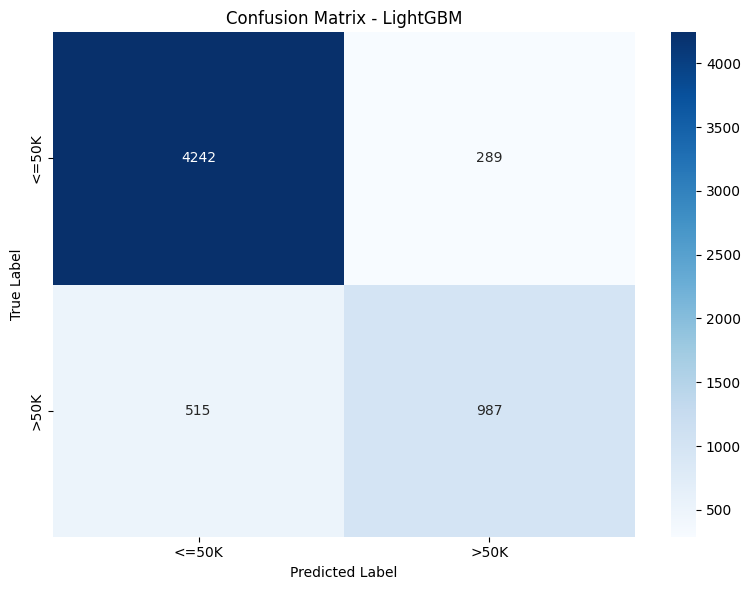

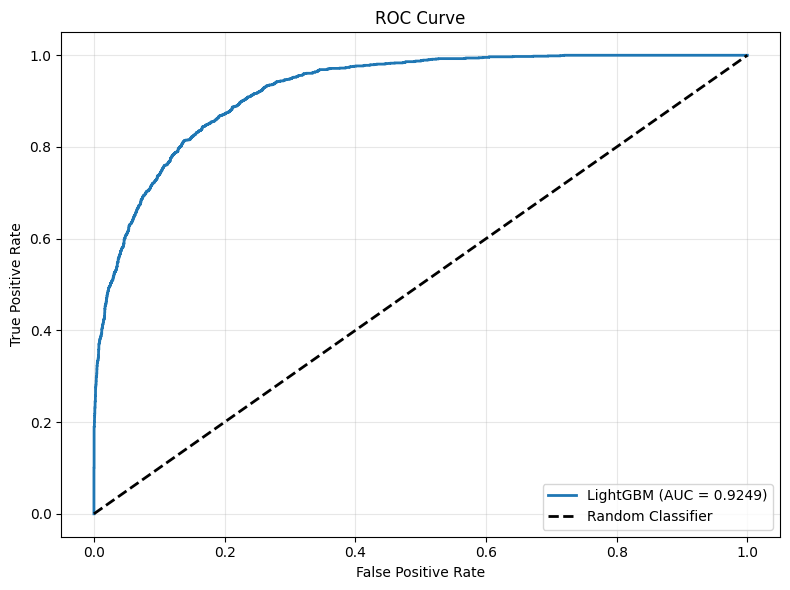

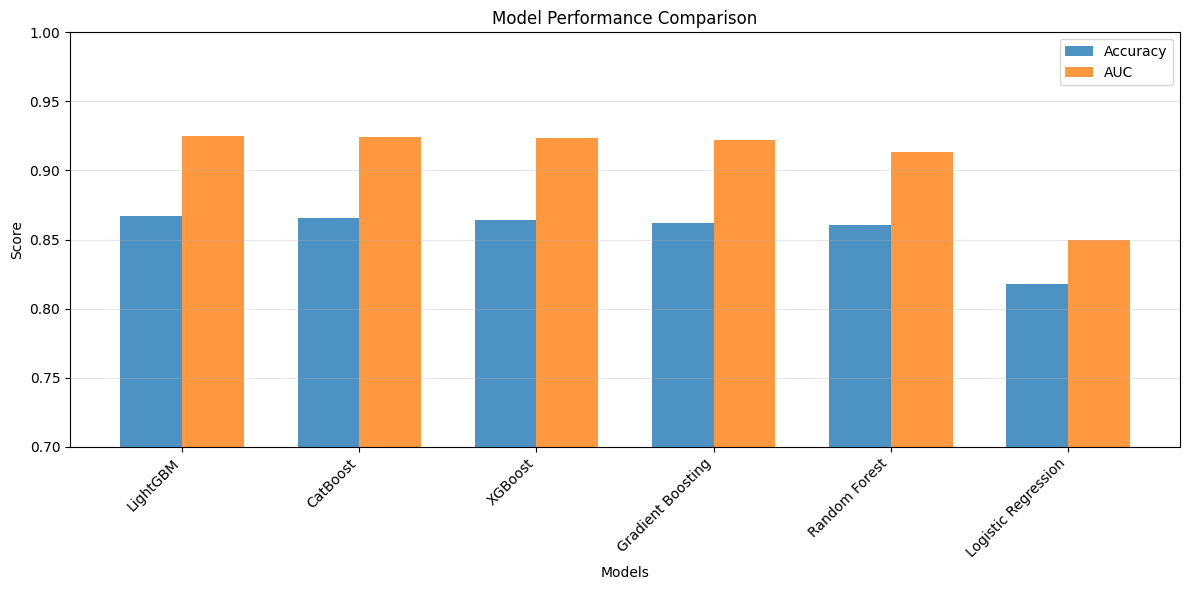

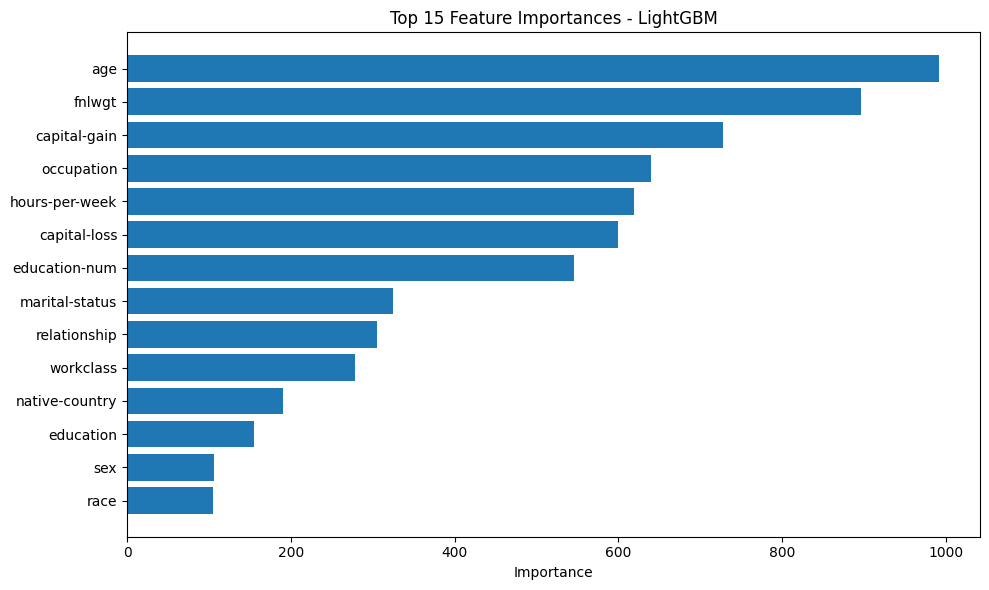


Top 10 Most Important Features:
       feature  importance
           age         992
        fnlwgt         896
  capital-gain         728
    occupation         640
hours-per-week         619
  capital-loss         600
 education-num         546
marital-status         325
  relationship         305
     workclass         278


In [10]:
print("\n" + "="*70)
print(f"DETAILED EVALUATION - {best_model_name}")
print("="*70)

# Predictions
y_pred_best = best_model.predict(X_test)
y_pred_proba_best = best_model.predict_proba(X_test)[:, 1]

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_best,
                          target_names=['<=50K', '>50K']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['<=50K', '>50K'],
            yticklabels=['<=50K', '>50K'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'{best_model_name} (AUC = {comparison_df.iloc[0]["AUC"]:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

# Model Comparison Chart
plt.figure(figsize=(12, 6))
x = np.arange(len(comparison_df))
width = 0.35

plt.bar(x - width/2, comparison_df['Accuracy'], width, label='Accuracy', alpha=0.8)
plt.bar(x + width/2, comparison_df['AUC'], width, label='AUC', alpha=0.8)

plt.xlabel('Models')
plt.ylabel('Score')
plt.title('Model Performance Comparison')
plt.xticks(x, comparison_df['Model'], rotation=45, ha='right')
plt.legend()
plt.ylim([0.7, 1.0])
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Feature Importance (if available)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': preprocessor.feature_names,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance['feature'], feature_importance['importance'])
    plt.xlabel('Importance')
    plt.title(f'Top 15 Feature Importances - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))

SAVING

In [11]:
print("\n" + "="*70)
print("SAVING MODEL AND ARTIFACTS")
print("="*70)

# Save best model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("Best model saved: best_model.pkl")

# Save preprocessor
preprocessor.save('preprocessor.pkl')

# Save metadata
metadata = {
    'best_model_name': best_model_name,
    'accuracy': float(best_accuracy),
    'auc': float(comparison_df.iloc[0]['AUC']),
    'best_params': all_results[best_model_name]['params'],
    'feature_names': preprocessor.feature_names,
    'all_results': {k: {'accuracy': float(v['accuracy']),
                        'auc': float(v['auc']),
                        'params': v['params']}
                   for k, v in all_results.items()}
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("Metadata saved: model_metadata.json")

# Save comparison results
comparison_df.to_csv('model_comparison.csv', index=False)
print("Comparison saved: model_comparison.csv")


SAVING MODEL AND ARTIFACTS
Best model saved: best_model.pkl
Preprocessor saved to preprocessor.pkl
Metadata saved: model_metadata.json
Comparison saved: model_comparison.csv


In [ ]:
print("\n" + "="*70)
print("DOWNLOAD FILES TO YOUR COMPUTER")
print("="*70)

print("\nDownloading files...")
files.download('best_model.pkl')
files.download('preprocessor.pkl')
files.download('model_metadata.json')
files.download('model_comparison.csv')
